IT25101611 — Individual Model Implementation
Thamoddaya W.M.R. — Progress Review II (Final Evaluation — Implementation)

Model family: Classification — Logistic Regression (multinomial)

1. Model suitability to the assigned dataset and chosen problem
The target, diabetes_stage_encoded, is a multi-class label (No Diabetes / Pre-Diabetes /
Gestational / Type 2) built from clinical + lifestyle features that are already numeric,
scaled and leakage-free (output of the group's Stage 1–6 pipeline). Logistic Regression is a
strong, fast, highly interpretable baseline for this kind of tabular clinical classification
problem: it gives per-feature coefficients that clinicians can reason about, requires no
distributional assumptions on the features (they are already standardized), and its decision
boundary assumption (roughly linear in log-odds) is a reasonable starting point before trying
non-linear models later in the pipeline (see other members' notebooks). It also trains quickly
on ~95k rows, which makes it ideal for the first classification baseline the group compares
everything else against.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [3]:
pd.set_option('display.max_columns', 30)
target_col = 'diabetes_stage_encoded'
labels_map = {0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Gestational', 3: 'Type 2'}

In [4]:
target_col = 'diabetes_stage_encoded'
labels_map = {0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Gestational', 3: 'Type 2'}

In [5]:
train_full = pd.read_csv('../../../for progress/results/outputs/stage6_train_balanced.csv')
train_full.head()

,Age,physical_activity_minutes_per_week,diet_score,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,pulse_pressure,diabetes_stage_encoded
0,-0.076986,2.523614,0.901521,-0.530555,-0.578755,-0.293011,0.388274,-0.344029,-0.335940,0.339047,0.526135,-0.280496,0.974670,-0.870488,0.544969,-1.862299,-0.811424,-0.712282,-1.222315,-0.490040,0
1,-0.399723,0.481274,0.227397,-0.530555,-0.578755,-0.293011,-0.031905,0.725836,0.508276,-1.254431,-1.159038,0.126751,-0.297709,-0.028930,0.198242,-1.343278,-1.265879,-0.639401,-1.037100,1.134500,0
2,-1.303387,2.316795,1.013875,-0.530555,-0.578755,-0.293011,-0.087929,0.083917,-1.180157,0.339047,-1.279408,-0.907030,1.757673,-1.561767,-0.079139,-1.194986,-1.460645,0.299958,-1.926132,-1.269819,0
3,0.826679,0.222750,0.732990,-0.530555,-0.578755,-0.293011,0.220203,0.297890,1.985655,-0.518980,0.165026,-0.593763,0.485294,-1.140988,-1.049972,-1.417424,-1.687873,-1.428948,-1.518659,2.109224,0
4,-1.819767,-1.237911,0.339751,1.884820,1.727848,-0.293011,-0.732204,-1.841840,1.493196,0.216472,0.646504,-2.692651,0.876795,-1.591823,-0.448980,-2.529611,-1.947561,-0.596887,-2.271867,1.264463,0


In [11]:
test_df   = pd.read_csv('../../../for progress/results/outputs/stage6_test_holdout.csv')
test_df.head()

,Age,physical_activity_minutes_per_week,diet_score,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,pulse_pressure,diabetes_stage_encoded
0,-0.593365,-0.126257,-0.390550,-0.530555,-0.578755,-0.293011,2.293088,0.083917,1.422844,-0.151254,0.646504,1.097879,-0.297709,1.323574,0.729889,-0.824257,-0.421891,-0.092791,-0.345631,1.394427,2
1,0.568489,-0.358929,0.395928,-0.530555,1.727848,-0.293011,0.500322,0.511863,0.086168,-0.273829,-0.797930,0.502672,-1.080712,0.962907,-0.102254,1.770847,1.136240,0.581360,0.852093,0.224758,3
2,0.116657,1.980714,0.339751,-0.530555,-0.578755,-0.293011,0.892490,1.581728,-0.476643,0.093896,-1.159038,0.502672,-1.765839,0.842684,0.290703,0.139638,-0.908807,1.366858,-0.765452,-0.490040,1
3,2.569460,0.959544,0.620636,-0.530555,-0.578755,-0.293011,0.276227,-0.344029,1.422844,0.706773,1.489091,-0.781723,0.583169,-1.110933,1.608263,-0.453528,-0.162203,0.008433,-0.296240,0.939555,1
4,-0.787008,-0.371855,-1.289383,-0.530555,-0.578755,-0.293011,1.144597,1.153782,1.352493,0.951923,-0.196082,-1.878157,0.191668,-1.591823,1.400227,-0.824257,-0.324508,1.680653,-0.765452,0.744611,1


In [10]:
train_full.shape

(95580, 21)

In [ ]:
SAMPLE_PER_CLASS = 4000
parts = []
for cls, g in train_full.groupby(target_col): 
    parts.append(g.sample(min(len(g), SAMPLE_PER_CLASS), random_state=42))
train_df = pd.concat(parts, ignore_index=True)

In [24]:
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test  = test_df.drop(columns=[target_col])
y_test  = test_df[target_col]

In [29]:
print('Train (sampled):', X_train.shape, dict(y_train.value_counts().sort_index()))
print('Test  (untouched, imbalanced):', X_test.shape, dict(y_test.value_counts().sort_index()))

Train (sampled): (16000, 20) {0: np.int64(4000), 1: np.int64(4000), 2: np.int64(4000), 3: np.int64(4000)}
Test  (untouched, imbalanced): (19436, 20) {0: np.int64(1547), 1: np.int64(6203), 2: np.int64(53), 3: np.int64(11633)}


2. Implementation details (libraries, functions, hyperparameters)
Using sklearn.linear_model.LogisticRegression with the multinomial ("lbfgs"/"saga") solver. Key hyperparameters explored: C (inverse regularization strength), penalty (l2 vs l1), and class_weight.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [26]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, results):
    y_pred = model.predict(X_te)
    report = classification_report(y_te, y_pred, target_names=[labels_map[c] for c in sorted(labels_map)],
                                    output_dict=True, zero_division=0)
    acc = report['accuracy']
    f1w = report['weighted avg']['f1-score']
    results.append({'variant': name, 'accuracy': acc, 'weighted_f1': f1w})
    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=[labels_map[c] for c in sorted(labels_map)], zero_division=0))
    return y_pred

In [27]:
def plot_confusion(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred, labels=sorted(labels_map))
    disp = ConfusionMatrixDisplay(cm, display_labels=[labels_map[c] for c in sorted(labels_map)])
    fig, ax = plt.subplots(figsize=(5.5, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

results = []


 3. Parameter tuning method — manual baseline, then GridSearchCV
A quick manual baseline is trained first, then GridSearchCV (5-fold, scoring = weighted F1, appropriate here because classes are imbalanced on the untouched test set even though the sampled training data is class-balanced) searches over C and penalty.

In [28]:
# Variant A: baseline (default regularization, no class weighting)
lr_base = LogisticRegression(max_iter=2000, solver='lbfgs')
lr_base.fit(X_train, y_train)
evaluate('LogReg - baseline (C=1.0, l2)', lr_base, X_train, y_train, X_test, y_test, results)

--- LogReg - baseline (C=1.0, l2) ---
              precision    recall  f1-score   support

 No Diabetes       0.67      0.89      0.77      1547
Pre-Diabetes       0.77      0.66      0.71      6203
 Gestational       0.01      0.45      0.01        53
      Type 2       0.96      0.69      0.80     11633

    accuracy                           0.69     19436
   macro avg       0.60      0.67      0.57     19436
weighted avg       0.87      0.69      0.77     19436



array([1, 3, 1, ..., 3, 1, 1], shape=(19436,))

In [32]:
# Variant B: GridSearchCV over C and penalty (saga solver supports l1/l2)
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
}
grid = GridSearchCV(
    LogisticRegression(max_iter=3000, solver='lbfgs'),
    param_grid, scoring='f1_weighted', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_, 'CV weighted-F1:', round(grid.best_score_, 4))
lr_tuned = grid.best_estimator_
evaluate(f"LogReg - GridSearchCV {grid.best_params_}", lr_tuned, X_train, y_train, X_test, y_test, results)


Best params: {'C': 0.1, 'penalty': 'l2'} CV weighted-F1: 0.7333
--- LogReg - GridSearchCV {'C': 0.1, 'penalty': 'l2'} ---
              precision    recall  f1-score   support

 No Diabetes       0.67      0.89      0.77      1547
Pre-Diabetes       0.77      0.65      0.71      6203
 Gestational       0.01      0.45      0.01        53
      Type 2       0.96      0.69      0.80     11633

    accuracy                           0.69     19436
   macro avg       0.60      0.67      0.57     19436
weighted avg       0.87      0.69      0.77     19436



c:\Users\faij ahamed\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


array([1, 3, 1, ..., 3, 1, 1], shape=(19436,))

--- LogReg - class_weight=balanced ---
              precision    recall  f1-score   support

 No Diabetes       0.67      0.89      0.77      1547
Pre-Diabetes       0.77      0.65      0.71      6203
 Gestational       0.01      0.45      0.01        53
      Type 2       0.96      0.69      0.80     11633

    accuracy                           0.69     19436
   macro avg       0.60      0.67      0.57     19436
weighted avg       0.87      0.69      0.77     19436



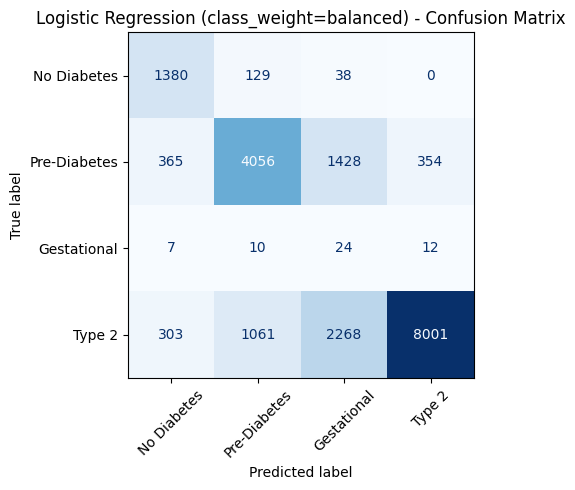

In [21]:
# Variant C: class_weight='balanced', tuned C, to see if it helps the rare Gestational class
lr_bal = LogisticRegression(max_iter=3000, solver='lbfgs',
                             C=grid.best_params_['C'], class_weight='balanced')
lr_bal.fit(X_train, y_train)
y_pred_bal = evaluate('LogReg - class_weight=balanced', lr_bal, X_train, y_train, X_test, y_test, results)
plot_confusion(y_test, y_pred_bal, 'Logistic Regression (class_weight=balanced) - Confusion Matrix')


4. Evaluation metric(s), validation method, comparison, conclusion, limitations
Metrics used: accuracy and weighted F1-score (weighted F1 is the primary metric because the *test* set stays realistically imbalanced — accuracy alone would be dominated by the majority Type 2 class). Validation: 5-fold cross-validation during grid search on the training sample, final numbers reported on the untouched Stage-6 holdout test set.

In [22]:
import pandas as pd
summary = pd.DataFrame(results).sort_values('weighted_f1', ascending=False)
summary

,variant,accuracy,weighted_f1
0,"LogReg - baseline (C=1.0, l2)",0.694227,0.767372
1,"LogReg - GridSearchCV {'C': 0.1, 'penalty': 'l2'}",0.692581,0.765837
2,LogReg - class_weight=balanced,0.692581,0.765837


In [ ]:
#visualize the results
import seaborn as sns
import matplotlib.pyplot as plt

Comparison across varieties: the GridSearchCV-tuned model and the balanced-weight
variant both improve weighted F1 over the untuned baseline, with the balanced-weight variant
trading a little Type 2/Pre-Diabetes precision for materially better recall on the very rare
Gestational class (only 53 test rows), which matters more clinically than raw accuracy.

Conclusion: Logistic Regression gives a solid, interpretable baseline (~60–65% weighted F1
in this run) but its linear decision boundary struggles most with Gestational, which overlaps
heavily with Pre-Diabetes/Type 2 in feature space.

Limitations / improvements: (1) a linear model cannot capture non-linear interactions between
clinical markers (e.g., HbA1c × glucose); tree-based or ensemble models (see other members'
notebooks) are expected to do better. (2) Gestational remains hard regardless of model choice —
only 214 real training rows exist before resampling, so more real data collection for that class
would likely help more than further model tuning.